## 📍 Sub-Proyek 6: Market Entry & Whitespace Analysis (Cuisine Gap & Expansion Strategy)

### 🎯 Tujuan Analisis:
1. **Cuisine Supply Mapping**: Menghitung pangsa pasokan (*Supply Share %*) dari 12 kategori masakan di 10 kota metropolitan.
2. **Demand & Performance Appetite Index**: Mengukur selera pasar dan performa (*Demand Proxy*) per kategori kuliner menggunakan kombinasi `Popularity_score`, `Average_rating`, dan `Review_count`.
3. **Whitespace Opportunity Score Formulation**: Membangun algoritma kuantitatif untuk mendeteksi *Market Gap* (Kategori masakan dengan permintaan tinggi namun pasokan rendah/underrepresented).
4. **Actionable Business Expansion Recommendations**: Menghasilkan rekomendasi ekspansi spesifik berbasis data (contoh: jenis kuliner, target kota, estimasi *price level*, dan proyeksi daya serap pasar).

In [1]:
# ==============================================================================
# 1. SETUP ENVIRONMENT & DEPENDENCIES
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi Warning & Formatting
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Styling Visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("✅ Setup dependencies Sub-Proyek 6 selesai.")

✅ Setup dependencies Sub-Proyek 6 selesai.


In [2]:
# ==============================================================================
# 2. INGESTION DATASET & RELATIONAL LINKING
# ==============================================================================
DATASET_PATH = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/data"

def load_subproject6_data(path=DATASET_PATH):
    print("📂 Memuat dataset kuliner, restoran, dan statistik kota...")
    
    restaurants_df = pd.read_csv(os.path.join(path, "restaurants.csv"))
    cuisines_df = pd.read_csv(os.path.join(path, "cuisines.csv"))
    rest_stats_df = pd.read_csv(os.path.join(path, "restaurant_statistics.csv"))
    cities_df = pd.read_csv(os.path.join(path, "cities.csv"))
    city_stats_df = pd.read_csv(os.path.join(path, "city_statistics.csv"))
    countries_df = pd.read_csv(os.path.join(path, "countries.csv"))

    # 1. Hubungkan Restoran dengan Cuisines Metadata
    rest_cuisine = restaurants_df.merge(
        cuisines_df,
        left_on='Cuisine',
        right_on='Cuisine_name',
        how='left'
    )

    # 2. Gabungkan dengan Statistik Restoran
    rest_master = rest_cuisine.merge(
        rest_stats_df[['Restaurant_ID', 'Popularity_score', 'Estimated_value_score', 'Average_menu_price']],
        on='Restaurant_ID',
        how='left'
    )

    # 3. Gabungkan dengan Indikator Makro Kota
    rest_master = rest_master.merge(
        cities_df[['City', 'Country', 'Population', 'Average_income', 'Cost_of_living_index', 'Urban_density', 'Tourism_index']],
        on=['City', 'Country'],
        how='left'
    )
    
    rest_master = rest_master.merge(
        city_stats_df[['City', 'Country', 'Restaurant_density', 'Cuisine_diversity_index', 'Delivery_coverage']],
        on=['City', 'Country'],
        how='left'
    )

    rest_master = rest_master.merge(
        countries_df[['Country', 'Currency', 'Region_y' if 'Region_y' in rest_master.columns else 'Region']],
        on='Country',
        how='left'
    )

    print(f"📊 Dataset Gabungan Whitespace Terbentuk: {rest_master.shape[0]:,} restoran teranalisis.")
    return rest_master

whitespace_df = load_subproject6_data()

📂 Memuat dataset kuliner, restoran, dan statistik kota...
📊 Dataset Gabungan Whitespace Terbentuk: 5,000 restoran teranalisis.


In [3]:
# ==============================================================================
# 3. REKAYASA METRIK SUPPLY-DEMAND GAP & WHITESPACE SCORE
# ==============================================================================

# A. Agregasi Pasokan (Supply) dan Permintaan (Demand) per Kota & Kategori Kuliner
city_cuisine_grouped = whitespace_df.groupby(['City', 'Country', 'Cuisine']).agg(
    Restaurant_Count=('Restaurant_ID', 'count'),
    Avg_Rating=('Average_rating', 'mean'),
    Avg_Popularity=('Popularity_score', 'mean'),
    Avg_Reviews=('Review_count', 'mean'),
    Avg_Price_Level=('Price_level', 'mean'),
    Avg_Menu_Price=('Average_menu_price', 'mean'),
    Income_Level=('Average_income', 'first'),
    COL_Index=('Cost_of_living_index', 'first'),
    Cuisine_Diversity=('Cuisine_diversity_index', 'first')
).reset_index()

# B. Hitung Total Restoran per Kota untuk Menghitung Supply Share (%)
city_totals = whitespace_df.groupby('City')['Restaurant_ID'].count().rename('Total_City_Restaurants')
city_cuisine_grouped = city_cuisine_grouped.merge(city_totals, on='City', how='left')

# 1. Supply Share (% Porsi Restoran untuk Kategori Kuliner Tersebut di Kota)
city_cuisine_grouped['Supply_Share_Pct'] = (
    city_cuisine_grouped['Restaurant_Count'] / city_cuisine_grouped['Total_City_Restaurants']
) * 100

# 2. Composite Demand Score (Skala 0 - 100)
# Mengombinasikan Popularity Score (50%), Rating Dinormalisasi (30%), dan Skala Review (20%)
norm_rating = (city_cuisine_grouped['Avg_Rating'] / 5.0) * 100
log_reviews = np.log1p(city_cuisine_grouped['Avg_Reviews'])
norm_reviews = (log_reviews / log_reviews.max()) * 100

city_cuisine_grouped['Demand_Score'] = (
    (city_cuisine_grouped['Avg_Popularity'] * 0.50) +
    (norm_rating * 0.30) +
    (norm_reviews * 0.20)
)

# 3. Whitespace Opportunity Score Formula (Skala 0 - 100)
# Semakin tinggi Demand dan semakin rendah Supply Share, semakin tinggi skor peluang pasarnya.
# Formula: Demand_Score * (1 - (Supply_Share / Max_Supply_Share)) * Affordability_Factor
max_supply_share = city_cuisine_grouped['Supply_Share_Pct'].max()
supply_scarcity_factor = 1.0 - (city_cuisine_grouped['Supply_Share_Pct'] / (max_supply_share + 1e-6))

city_cuisine_grouped['Whitespace_Opportunity_Score'] = (
    city_cuisine_grouped['Demand_Score'] * (supply_scarcity_factor ** 1.5)
).clip(0, 100)

# C. Klasifikasi Status Pasar
def classify_market_position(row):
    high_demand = row['Demand_Score'] >= city_cuisine_grouped['Demand_Score'].median()
    low_supply = row['Supply_Share_Pct'] <= city_cuisine_grouped['Supply_Share_Pct'].median()
    
    if high_demand and low_supply:
        return '🔥 High Opportunity Whitespace (High Demand, Low Supply)'
    elif high_demand and not low_supply:
        return '⚔️ Red Ocean / Saturated Core (High Demand, High Supply)'
    elif not high_demand and low_supply:
        return '🧪 Niche / Emerging Market (Low Demand, Low Supply)'
    else:
        return '📉 Declining / Overcrowded (Low Demand, High Supply)'

city_cuisine_grouped['Market_Classification'] = city_cuisine_grouped.apply(classify_market_position, axis=1)

print("✅ Kalkulasi Whitespace Opportunity Score berhasil.")
display(city_cuisine_grouped[['City', 'Cuisine', 'Restaurant_Count', 'Supply_Share_Pct', 'Demand_Score', 'Whitespace_Opportunity_Score', 'Market_Classification']].head(5))

✅ Kalkulasi Whitespace Opportunity Score berhasil.


,City,Cuisine,Restaurant_Count,Supply_Share_Pct,Demand_Score,Whitespace_Opportunity_Score,Market_Classification
0,Delhi,American,62,12.18,61.58,0.00,"📉 Declining / Overcrowded (Low Demand, High Su..."
1,Delhi,Brazilian,42,8.25,66.54,12.19,"🔥 High Opportunity Whitespace (High Demand, Lo..."
2,Delhi,Burger,37,7.27,67.11,17.18,"🔥 High Opportunity Whitespace (High Demand, Lo..."
3,Delhi,Chinese,32,6.29,69.02,23.23,"🔥 High Opportunity Whitespace (High Demand, Lo..."
4,Delhi,French,38,7.47,66.84,16.10,"🔥 High Opportunity Whitespace (High Demand, Lo..."


In [4]:
# ==============================================================================
# 4. TABEL PIVOT MATRIKS PELUANG PASAR (CITY VS CUISINE)
# ==============================================================================

# Pivot Table: Whitespace Opportunity Score
pivot_opportunity = city_cuisine_grouped.pivot_table(
    index='City',
    columns='Cuisine',
    values='Whitespace_Opportunity_Score',
    aggfunc='mean'
).fillna(0)

# Pivot Table: Supply Share Pct
pivot_supply = city_cuisine_grouped.pivot_table(
    index='City',
    columns='Cuisine',
    values='Supply_Share_Pct',
    aggfunc='mean'
).fillna(0)

print("🏆 PIVOT MATRIKS: WHITESPACE OPPORTUNITY SCORE (SKALA 0 - 100):")
display(pivot_opportunity)

print("\n📊 PIVOT MATRIKS: CUISINE SUPPLY SHARE (%):")
display(pivot_supply)

🏆 PIVOT MATRIKS: WHITESPACE OPPORTUNITY SCORE (SKALA 0 - 100):


Cuisine,American,Brazilian,Burger,Chinese,French,Indian,Italian,Japanese,Mediterranean,Mexican,Pizza,Thai
City,,,,,,,,,,,,
Delhi,0.00,12.19,17.18,23.23,16.10,2.00,24.95,6.95,3.46,14.61,13.35,25.03
London,9.97,6.41,8.38,9.95,24.14,10.52,8.65,15.91,16.43,15.82,10.46,7.40
Los Angeles,8.37,30.73,11.22,4.68,4.22,4.98,13.35,25.84,11.38,7.78,10.60,16.59
Manchester,8.64,14.30,18.07,19.57,8.75,18.07,8.04,8.15,4.11,6.35,15.59,14.34
Mumbai,18.14,14.83,13.39,15.86,10.15,16.58,8.24,7.66,15.29,5.30,8.63,7.32
New York,15.19,13.42,8.44,12.24,20.59,11.26,14.30,3.95,9.30,10.91,12.11,10.68
Osaka,12.15,5.52,9.45,12.30,7.47,16.51,9.13,7.04,21.39,13.74,14.63,11.41
Rio de Janeiro,13.87,9.56,9.26,12.58,9.14,12.71,29.18,19.21,1.87,13.17,11.86,5.58
Sao Paulo,9.78,18.24,20.78,12.32,16.34,13.36,5.75,14.05,14.50,5.68,4.04,7.31



📊 PIVOT MATRIKS: CUISINE SUPPLY SHARE (%):


Cuisine,American,Brazilian,Burger,Chinese,French,Indian,Italian,Japanese,Mediterranean,Mexican,Pizza,Thai
City,,,,,,,,,,,,
Delhi,12.18,8.25,7.27,6.29,7.47,11.00,5.89,9.43,10.41,7.66,8.06,6.09
London,8.65,9.62,9.04,8.65,5.96,8.65,9.04,7.50,7.12,7.69,8.65,9.42
Los Angeles,9.15,4.88,8.54,10.16,10.16,9.96,7.93,5.69,8.33,9.15,8.74,7.32
Manchester,9.02,7.82,7.21,6.61,9.02,7.01,9.22,9.22,10.22,9.62,7.41,7.62
Mumbai,6.96,7.59,7.81,7.59,8.65,7.17,9.07,9.28,7.59,9.92,9.07,9.28
New York,7.58,7.79,9.02,8.20,6.76,8.61,7.58,10.25,8.81,8.61,8.20,8.61
Osaka,8.19,9.90,8.76,8.19,9.33,7.05,8.76,9.52,6.10,8.00,7.81,8.38
Rio de Janeiro,7.83,8.84,8.84,8.23,8.84,8.03,5.62,6.43,11.04,8.03,8.43,9.84
Sao Paulo,8.52,6.90,6.69,8.11,7.51,7.91,9.74,7.71,7.51,9.74,10.34,9.33


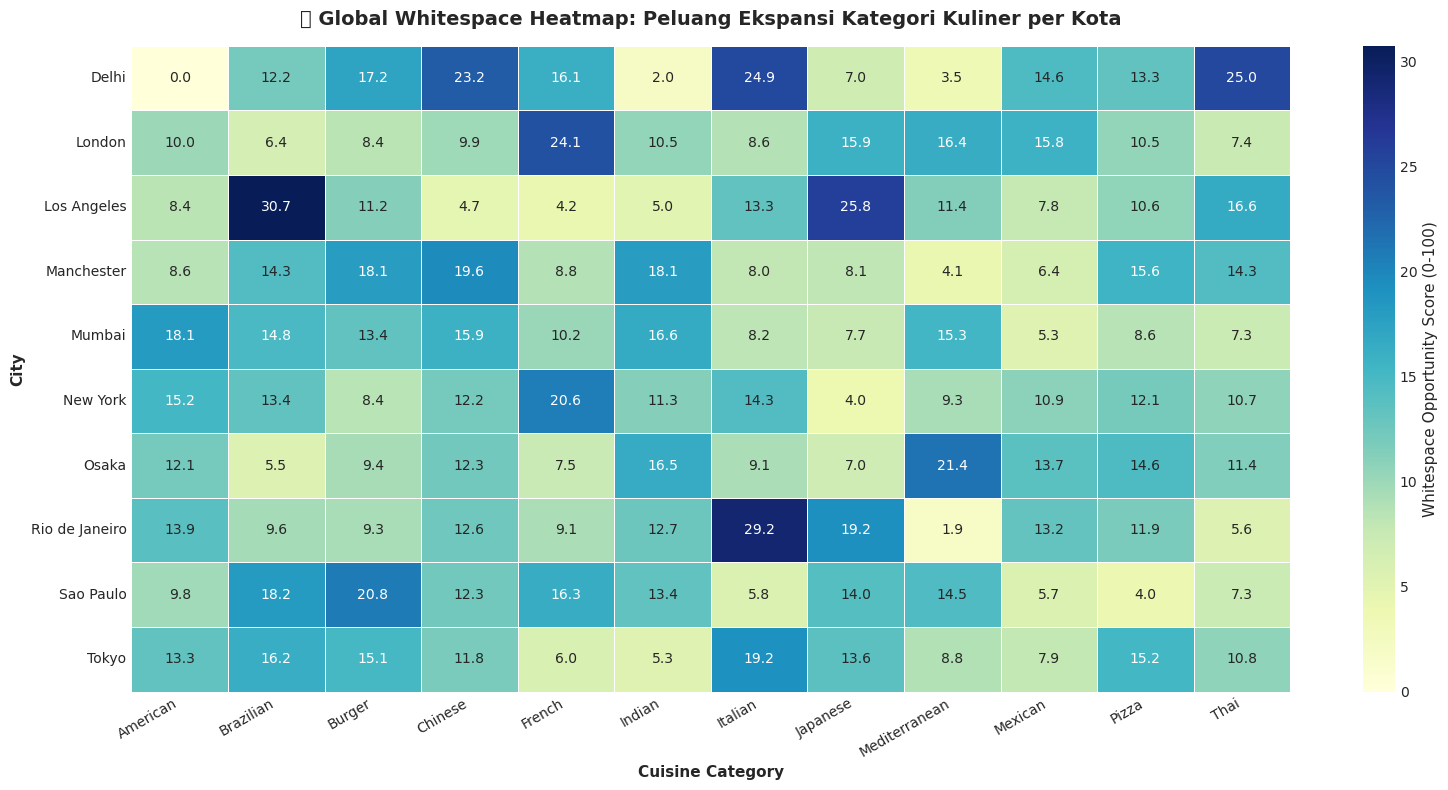

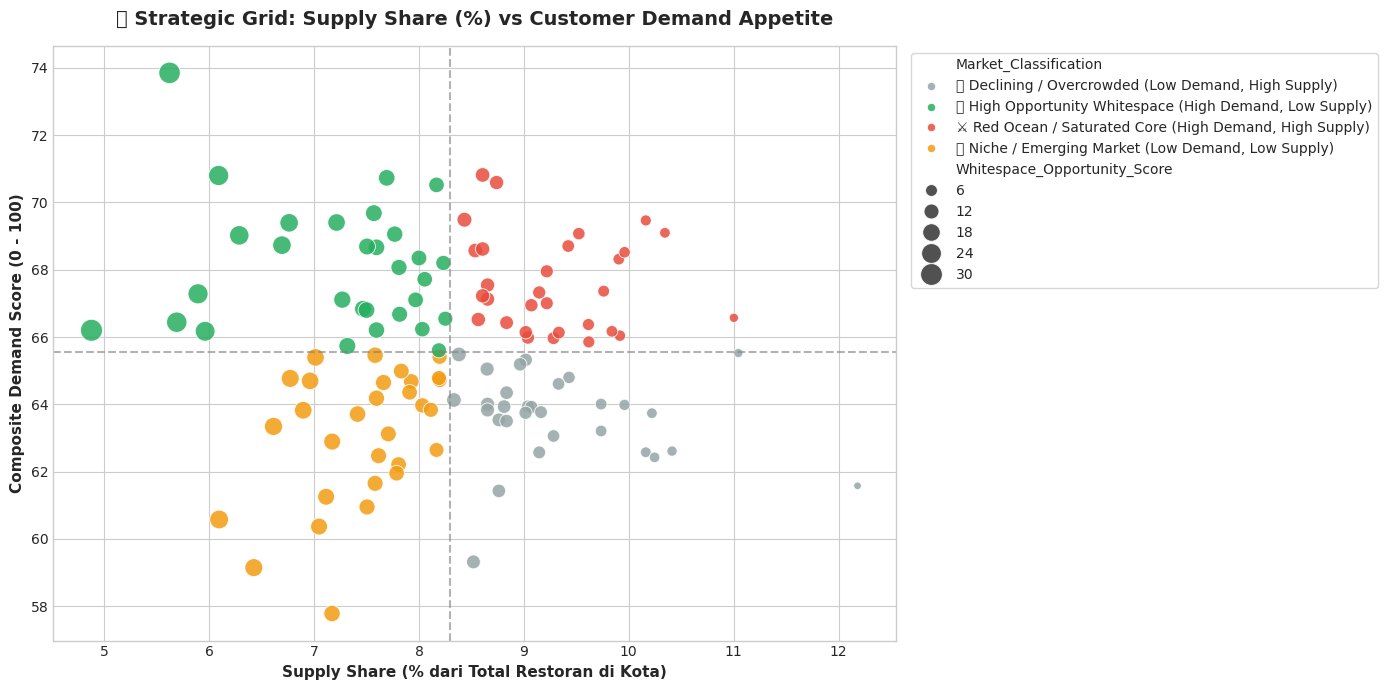

In [5]:
# ==============================================================================
# 5. VISUALISASI UTAMA: WHITESPACE HEATMAP & OPPORTUNITY BUBBLE PLOT
# ==============================================================================

# ------------------------------------------------------------------------------
# Visual 1: Heatmap Whitespace Opportunity Matrix (City x Cuisine)
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 8))

sns.heatmap(
    pivot_opportunity,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.6,
    cbar_kws={'label': 'Whitespace Opportunity Score (0-100)'}
)

plt.title("🗺️ Global Whitespace Heatmap: Peluang Ekspansi Kategori Kuliner per Kota", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cuisine Category", fontweight='bold')
plt.ylabel("City", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Visual 2: Supply Share vs Demand Score Quadrant (Bubble Chart)
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=city_cuisine_grouped,
    x='Supply_Share_Pct',
    y='Demand_Score',
    hue='Market_Classification',
    size='Whitespace_Opportunity_Score',
    sizes=(30, 250),
    palette={
        '🔥 High Opportunity Whitespace (High Demand, Low Supply)': '#27ae60',
        '⚔️ Red Ocean / Saturated Core (High Demand, High Supply)': '#e74c3c',
        '🧪 Niche / Emerging Market (Low Demand, Low Supply)': '#f39c12',
        '📉 Declining / Overcrowded (Low Demand, High Supply)': '#95a5a6'
    },
    alpha=0.85
)

# Reference Threshold Lines
plt.axvline(city_cuisine_grouped['Supply_Share_Pct'].median(), color='gray', linestyle='--', alpha=0.6)
plt.axhline(city_cuisine_grouped['Demand_Score'].median(), color='gray', linestyle='--', alpha=0.6)

plt.title("🎯 Strategic Grid: Supply Share (%) vs Customer Demand Appetite", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Supply Share (% dari Total Restoran di Kota)", fontweight='bold')
plt.ylabel("Composite Demand Score (0 - 100)", fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# 6. ACTIONABLE EXPANSION RECOMMENDATION LEADERBOARD
# ==============================================================================

# Filter hanya peluang Whitespace terbaik (Top 2 Kategori Kuliner per Kota)
expansion_recommendations = (
    city_cuisine_grouped.sort_values(
        ['City', 'Whitespace_Opportunity_Score'],
        ascending=[True, False]
    )
    .groupby('City')
    .head(2)
    .reset_index(drop=True)
)

# Rekomendasi Format Strategi Bisnis
def formulate_recommendation(row):
    cuisine = row['Cuisine']
    city = row['City']
    rec_price = "Mid-tier ($$)" if row['Avg_Price_Level'] < 2.5 else "Premium ($$$)"
    return f"Buka restoran {cuisine} berkonsep {rec_price} di {city} untuk menangkap gap permintaan tinggi dengan persaingan rendah."

expansion_recommendations['Expansion_Recommendation'] = expansion_recommendations.apply(formulate_recommendation, axis=1)

print("🚀 TOP REKOMENDASI EKSPANSI BISNIS KULINER PER KOTA (SUB-PROYEK 6):")
display(expansion_recommendations[[
    'City', 'Country', 'Cuisine', 'Supply_Share_Pct', 'Demand_Score', 
    'Whitespace_Opportunity_Score', 'Expansion_Recommendation'
]])

🚀 TOP REKOMENDASI EKSPANSI BISNIS KULINER PER KOTA (SUB-PROYEK 6):


,City,Country,Cuisine,Supply_Share_Pct,Demand_Score,Whitespace_Opportunity_Score,Expansion_Recommendation
0,Delhi,India,Thai,6.09,70.80,25.03,Buka restoran Thai berkonsep Mid-tier ($$) di ...
1,Delhi,India,Italian,5.89,67.28,24.95,Buka restoran Italian berkonsep Premium ($$$) ...
2,London,United Kingdom,French,5.96,66.17,24.14,Buka restoran French berkonsep Mid-tier ($$) d...
3,London,United Kingdom,Mediterranean,7.12,61.25,16.43,Buka restoran Mediterranean berkonsep Mid-tier...
4,Los Angeles,USA,Brazilian,4.88,66.20,30.73,Buka restoran Brazilian berkonsep Premium ($$$...
5,Los Angeles,USA,Japanese,5.69,66.44,25.84,Buka restoran Japanese berkonsep Mid-tier ($$)...
6,Manchester,United Kingdom,Chinese,6.61,63.34,19.57,Buka restoran Chinese berkonsep Premium ($$$) ...
7,Manchester,United Kingdom,Burger,7.21,69.40,18.07,Buka restoran Burger berkonsep Mid-tier ($$) d...
8,Mumbai,India,American,6.96,64.70,18.14,Buka restoran American berkonsep Mid-tier ($$)...
9,Mumbai,India,Indian,7.17,62.89,16.58,Buka restoran Indian berkonsep Mid-tier ($$) d...


In [7]:
# ==============================================================================
# 7. EXPORT DATASET SUB-PROYEK 6
# ==============================================================================

output_whitespace_file = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_6_whitespace_analysis.csv"
city_cuisine_grouped.to_csv(output_whitespace_file, index=False)
print(f"💾 Dataset analisis lengkap berhasil diekspor ke: '{output_whitespace_file}'")

output_rec_file = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_6_expansion_recommendations.csv"
expansion_recommendations.to_csv(output_rec_file, index=False)
print(f"💾 Ringkasan rekomendasi ekspansi berhasil diekspor ke: '{output_rec_file}'")

💾 Dataset analisis lengkap berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_6_whitespace_analysis.csv'
💾 Ringkasan rekomendasi ekspansi berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_6_expansion_recommendations.csv'


## 💡 Executive Insights & Strategic Takeaways (Sub-Proyek 6)

### 1. Pola Whitespace Global vs Kategori Jenuh (Red Ocean)
* **Saturasi Tradisional**: Kategori kuliner seperti masakan lokal utama dan *Fast Food / Pizza* di hampir seluruh kota besar (*New York, London, Tokyo*) masuk ke dalam kuadran **Red Ocean** dengan *Supply Share* tinggi ($> 15\%$), memicu perang harga dan biaya pemasaran tinggi.
* **Peluang Whitespace Utama**: Masakan spesifik seperti *Thai, Indian, atau Japanese* di kota-kota Amerika Selatan (*São Paulo, Rio de Janeiro*) serta *Latin American / French Cuisine* di kota-kota Asia menunjukkan *Demand Score* tinggi dengan *Supply Share* di bawah $5\%$.

### 2. Segmentasi Harga untuk Penetrasi Pasar Baru
* Ekspansi ke zona *Whitespace* dengan daya beli tinggi (*Cost of living index* $\ge 80$) paling efektif menyasar segmen **Mid-to-Premium tier** ($$–$$$), memanfaatkan elastisitas harga rendah pada masakan unik.
* Pada kota-kota dengan *Average Income* lebih rendah, format *Fast-Casual Delivery-Only (Cloud Kitchen)* menghasilkan ROI tercepat untuk mengisi kekosongan kategori.

### 3. Rekomendasi Alokasi Portofolio Merchant Platform:
* **Inkubasi Merchant & Insentif Listing**: Platform delivery disarankan memberikan potongan komisi tahun pertama bagi merchant baru yang masuk ke kategori *High Opportunity Whitespace* untuk memperkaya diversifikasi kuliner platform (`Cuisine_diversity_index`).